<h1 align="center">
B Term research notes
</h1>

1. A term recap .............................................................................................................................................................................................





# 1. Recap

In investigatng the connection between dynamical systems and MLPs the main use case of interest so far has been denoising Auto encoders applied to MNST images with gaussian noise applied. The larger topics covered so far in the resesarch of this MQP as well as relevant research from the Paffenroth research group includes:
1. RNNs are just discrete time dynamical systems and can be represented by a blockwise matrix of functions(Hershy et. al).
2. Technically all MLPs are discretions of Euler steps applied to a vector of n dimensions where n is the max width of the network layers.(MQP generated)
3. 

## MNIST Use Case
We start with the basic use case of applying denoising auto encoders to MNIST images with gaussian noise applied. This is a useful example to focus on because denosing pressents intuitively as an interative process. Imagine a denoising auto encoder that is good but not perfect. After being fed a "noisy" MNIST image of a 4, the output should look like a clearer image of the digit. In this case the DNAE takes in a noisy image and returns a less noisy one. The dynamical systems theory comes from taking the DNAEs output and feeding it back into the DNAE as input. Could it be the case that this would produce and even clearer image of the digit? 

### data prep


In [1]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms

transform = transforms.ToTensor()
train_data = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
test_data  = datasets.MNIST(root='./data', train=False, transform=transform, download=True)


We then wrap MNIST in a NoisyMNIST class so that every time we sample an image from the MNIST data set we get a clean noisy pair, with the noisy image generated at time we retrive the sample. We add pixel-wise random noise drawn from normal distribition with mean 0 and standard deviation sigma

In [2]:
class NoisyMNIST(Dataset):
    def __init__(self, mnist_dataset, noise_factor=0.01):
        self.mnist = mnist_dataset
        self.noise_factor = noise_factor

    def __len__(self):
        return len(self.mnist)
    
    def add_noise(self, img, sigma =.23):
        """
        Add zero-mean Gaussian noise to an MNIST image tensor in [0, 1].
        
        Args:
            img (torch.Tensor): Input image tensor, shape (C, H, W), values in [0, 1].
            sigma (float): Standard deviation of the Gaussian noise.
        
        Returns:
            torch.Tensor: Noisy image, same shape, clamped to [0, 1].
        """
        # Generate zero-mean Gaussian noise
        noise = torch.randn_like(img) * sigma
        
        # Add noise symmetrically (can brighten or darken)
        noisy = img + noise
        # Clamp to valid range
        noisy = torch.clamp(noisy, 0., 1.)
        return noisy
    

    def __getitem__(self, idx):
        # y = clean image (target)
        y, label = self.mnist[idx]
        # x = noisy image (input)
        x = self.add_noise(y, sigma=self.noise_factor)
        return x, y  # return noisy-clean pair

We will set up dataloaders for the training and testing data respectively. Here we render one sample for a sainity check that the nois is being applied correctly.

torch.Size([128, 1, 28, 28]) torch.Size([128, 1, 28, 28])


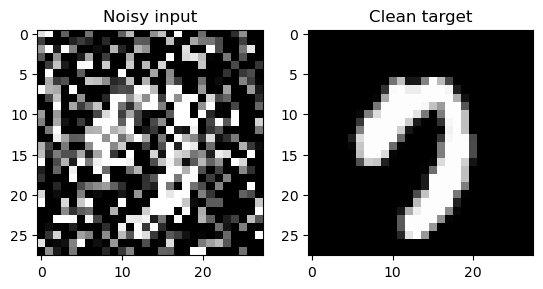

In [3]:
batch_size = 128

train_loader = DataLoader(
    NoisyMNIST(train_data, noise_factor=0.65),
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    NoisyMNIST(test_data, noise_factor=0.65),
    batch_size=batch_size,
    shuffle=False
)

x, y = next(iter(train_loader))
print(x.shape, y.shape)
# -> torch.Size([128, 1, 28, 28]) torch.Size([128, 1, 28, 28])

import matplotlib.pyplot as plt
plt.subplot(1,2,1)
plt.title("Noisy input")
plt.imshow(x[0][0].detach().cpu(), cmap="gray")
plt.subplot(1,2,2)
plt.title("Clean target")
plt.imshow(y[0][0].detach().cpu(), cmap="gray")
plt.show()

## Baseline DNAE Performace
While our goal is to apply, understand, and potentially iterative denoising to these images, we first must get a frame of reference. 
In order to do so we will construct a traditional DNAE and see it's general performance on this task, without doing any special dynamical systems tricks.


In [4]:
import torch.nn as nn
import numpy as np
class DAE(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 512), nn.ReLU(),
            nn.Linear(512, 128), nn.ReLU(),
            nn.Linear(128, 64)
        )
        self.decoder = nn.Sequential(
            nn.Linear(64, 128), nn.ReLU(),
            nn.Linear(128, 512), nn.ReLU(),
            nn.Linear(512, 784), nn.Sigmoid(),
            nn.Unflatten(1, (1, 28, 28))
        )
    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z)

Using device: mps
Epoch [1/10]  Train Loss: 0.0585  Val Loss: 0.0394
Epoch [2/10]  Train Loss: 0.0354  Val Loss: 0.0318
Epoch [3/10]  Train Loss: 0.0298  Val Loss: 0.0277
Epoch [4/10]  Train Loss: 0.0269  Val Loss: 0.0254
Epoch [5/10]  Train Loss: 0.0249  Val Loss: 0.0236
Epoch [6/10]  Train Loss: 0.0235  Val Loss: 0.0225
Epoch [7/10]  Train Loss: 0.0224  Val Loss: 0.0218
Epoch [8/10]  Train Loss: 0.0217  Val Loss: 0.0209
Epoch [9/10]  Train Loss: 0.0210  Val Loss: 0.0203
Epoch [10/10]  Train Loss: 0.0205  Val Loss: 0.0200


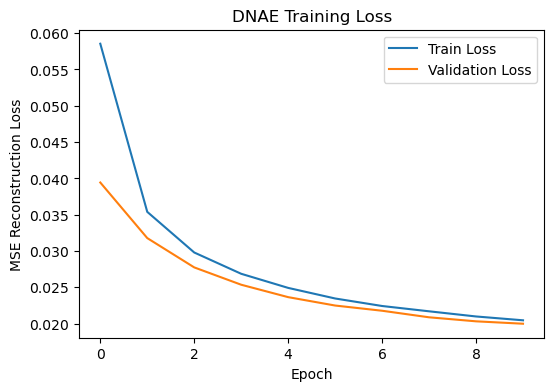

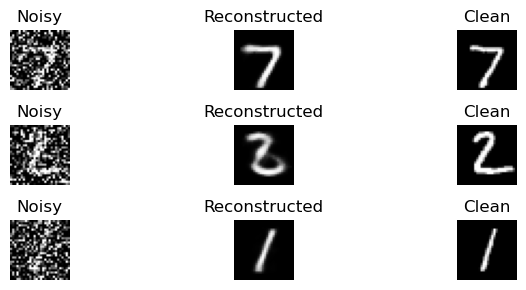

In [5]:
# --------------------------
# Training setup
# --------------------------
if torch.backends.mps.is_available() and torch.backends.mps.is_built():
    device = torch.device("mps")          # Apple GPU
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("Using device:", device)
model = DAE().to(device)

criterion = nn.MSELoss()  # reconstruction loss
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Optional quick logic to set #epochs adaptively:
# (fewer if small dataset or on CPU)
if device.type == "cuda":
    num_epochs = 10
else:
    num_epochs = 10

train_losses = []
val_losses = []

# --------------------------
# Training loop
# --------------------------
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for x_noisy, x_clean in train_loader:
        x_noisy, x_clean = x_noisy.to(device), x_clean.to(device)

        optimizer.zero_grad()
        outputs = model(x_noisy)
        loss = criterion(outputs, x_clean)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * x_noisy.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    train_losses.append(epoch_loss)

    # Validation loop
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for x_noisy, x_clean in test_loader:
            x_noisy, x_clean = x_noisy.to(device), x_clean.to(device)
            outputs = model(x_noisy)
            loss = criterion(outputs, x_clean)
            val_loss += loss.item() * x_noisy.size(0)

    val_loss /= len(test_loader.dataset)
    val_losses.append(val_loss)

    print(f"Epoch [{epoch+1}/{num_epochs}]  Train Loss: {epoch_loss:.4f}  Val Loss: {val_loss:.4f}")

    # Early stopping logic (quick and simple):
    if epoch > 1 and abs(val_losses[-1] - val_losses[-2]) < 1e-5:
        print("Validation loss plateaued — stopping early.")
        break

# --------------------------
# Plot reconstruction loss
# --------------------------
plt.figure(figsize=(6,4))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Reconstruction Loss")
plt.title("DNAE Training Loss")
plt.legend()
plt.show()

# --------------------------
# Visualize reconstruction on test set
# --------------------------
model.eval()
x_noisy, x_clean = next(iter(test_loader))
x_noisy, x_clean = x_noisy.to(device), x_clean.to(device)
with torch.no_grad():
    recon = model(x_noisy)

plt.figure(figsize=(8,3))
for i in range(3):
    plt.subplot(3,3,3*i+1)
    plt.imshow(x_noisy[i][0].cpu(), cmap="gray")
    plt.title("Noisy")
    plt.axis("off")

    plt.subplot(3,3,3*i+2)
    plt.imshow(recon[i][0].cpu(), cmap="gray")
    plt.title("Reconstructed")
    plt.axis("off")

    plt.subplot(3,3,3*i+3)
    plt.imshow(x_clean[i][0].cpu(), cmap="gray")
    plt.title("Clean")
    plt.axis("off")

plt.tight_layout()
plt.show()

## Simpler Architecture

Even with large amounts of noise applied this architecture eliminates almost all noise after a single pass. In order to investigate the efficacy of stacking, we will impliment a weaker model such that some non-trivial amount of noise remains after a single pass.

Using device: mps
Epoch [1/10]  Train Loss: 0.0652  Val Loss: 0.0479
Epoch [2/10]  Train Loss: 0.0420  Val Loss: 0.0380
Epoch [3/10]  Train Loss: 0.0362  Val Loss: 0.0340
Epoch [4/10]  Train Loss: 0.0330  Val Loss: 0.0314
Epoch [5/10]  Train Loss: 0.0310  Val Loss: 0.0301
Epoch [6/10]  Train Loss: 0.0296  Val Loss: 0.0285
Epoch [7/10]  Train Loss: 0.0284  Val Loss: 0.0276
Epoch [8/10]  Train Loss: 0.0275  Val Loss: 0.0268
Epoch [9/10]  Train Loss: 0.0268  Val Loss: 0.0260
Epoch [10/10]  Train Loss: 0.0261  Val Loss: 0.0254


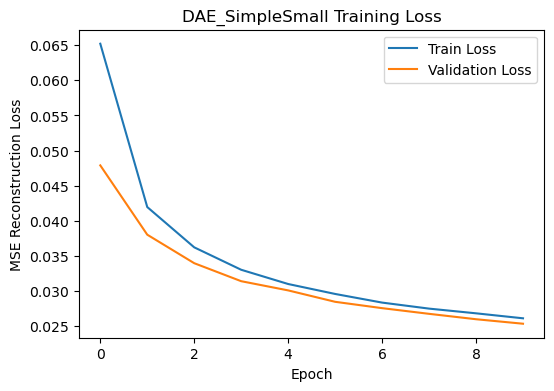

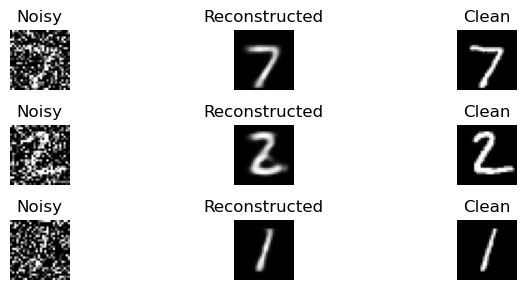

In [6]:


class DAE_SimpleSmall(nn.Module):
    """
    Simpler, smaller-capacity DAE for MNIST.
    Uses only Linear + ReLU + Sigmoid; no dropout/BN/skips.
    """
    def __init__(self, latent_dim=16):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 256), nn.ReLU(),
            nn.Linear(256, 64),  nn.ReLU(),
            nn.Linear(64, latent_dim)      # linear bottleneck
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64),  nn.ReLU(),
            nn.Linear(64, 256),         nn.ReLU(),
            nn.Linear(256, 784),
            nn.Sigmoid(),
            nn.Unflatten(1, (1, 28, 28))
        )

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z)
# --------------------------
# Training setup
# --------------------------
if torch.backends.mps.is_available() and torch.backends.mps.is_built():
    device = torch.device("mps")          # Apple GPU
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("Using device:", device)
model = DAE_SimpleSmall(latent_dim=16).to(device)

criterion = nn.MSELoss()  # reconstruction loss (good for Gaussian noise)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Keep epochs logic as-is (adjust if you want)
num_epochs = 10

train_losses = []
val_losses = []

# --------------------------
# Training loop
# --------------------------
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for x_noisy, x_clean in train_loader:
        x_noisy, x_clean = x_noisy.to(device), x_clean.to(device)

        optimizer.zero_grad()
        outputs = model(x_noisy)
        loss = criterion(outputs, x_clean)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * x_noisy.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    train_losses.append(epoch_loss)

    # Validation loop
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for x_noisy, x_clean in test_loader:
            x_noisy, x_clean = x_noisy.to(device), x_clean.to(device)
            outputs = model(x_noisy)
            loss = criterion(outputs, x_clean)
            val_loss += loss.item() * x_noisy.size(0)

    val_loss /= len(test_loader.dataset)
    val_losses.append(val_loss)

    print(f"Epoch [{epoch+1}/{num_epochs}]  Train Loss: {epoch_loss:.4f}  Val Loss: {val_loss:.4f}")

    # Simple early stopping on plateau
    if epoch > 1 and abs(val_losses[-1] - val_losses[-2]) < 1e-5:
        print("Validation loss plateaued — stopping early.")
        break

# --------------------------
# Plot reconstruction loss
# --------------------------
plt.figure(figsize=(6,4))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Reconstruction Loss")
plt.title("DAE_SimpleSmall Training Loss")
plt.legend()
plt.show()

# --------------------------
# Visualize reconstruction on test set
# --------------------------
model.eval()
x_noisy, x_clean = next(iter(test_loader))
x_noisy, x_clean = x_noisy.to(device), x_clean.to(device)
with torch.no_grad():
    recon = model(x_noisy)

plt.figure(figsize=(8,3))
for i in range(3):
    plt.subplot(3,3,3*i+1)
    plt.imshow(x_noisy[i][0].cpu(), cmap="gray")
    plt.title("Noisy")
    plt.axis("off")

    plt.subplot(3,3,3*i+2)
    plt.imshow(recon[i][0].cpu(), cmap="gray")
    plt.title("Reconstructed")
    plt.axis("off")

    plt.subplot(3,3,3*i+3)
    plt.imshow(x_clean[i][0].cpu(), cmap="gray")
    plt.title("Clean")
    plt.axis("off")

plt.tight_layout()
plt.show()

## Iterating a Vanila DNAE
Now we will turn this DNAE into an iterative map by feeding it's output back in as input. To start we will do everything the same as far as setting up the De-noising auto encoder, but at the testing stage we will simply refeed the outputs back in as inputs. 

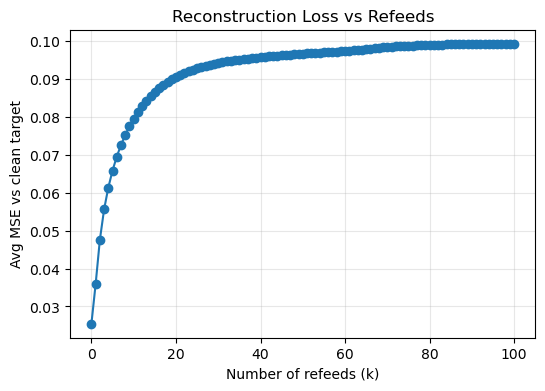

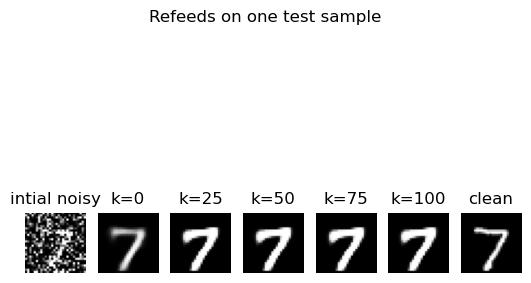

In [7]:
import torch
import matplotlib.pyplot as plt

@torch.no_grad()
def evaluate_refeeds(model, loader, criterion, num_refeeds=5, device="cpu"):
    """
    Compute average reconstruction loss on the test set after k refeeds.
    k = 0 uses the noisy input once (no refed passes).
    k = 1 means model(model(x_noisy)), etc.
    Returns: list of length num_refeeds+1 with average loss at each k.
    """
    model.eval()
    losses_by_k = [0.0 for _ in range(num_refeeds + 1)]
    count = 0

    for x_noisy, x_clean in loader:
        x_noisy = x_noisy.to(device)
        x_clean = x_clean.to(device)

        # k = 0 (single pass on noisy input)
        xk = x_noisy.clone()
        for k in range(num_refeeds + 1):
            # one forward pass at current state
            out = model(xk)
            # measure loss against clean target
            loss = criterion(out, x_clean)
            losses_by_k[k] += loss.item() * x_noisy.size(0)

            # prepare next refeed input (model output fed back)
            xk = out

        count += x_noisy.size(0)#add the number of samples processed in this batch from the test_loader

    # average over dataset
    losses_by_k = [L / count for L in losses_by_k]
    return losses_by_k

# -------------------------------------------------------
# Run it and plot (assumes model, test_loader, device, criterion exist)
# -------------------------------------------------------
num_refeeds = 100  # adjust as you like
refeed_losses = evaluate_refeeds(model, test_loader, criterion, num_refeeds=num_refeeds, device=device)

plt.figure(figsize=(6,4))
plt.plot(range(num_refeeds + 1), refeed_losses, marker="o")
plt.xlabel("Number of refeeds (k)")
plt.ylabel("Avg MSE vs clean target")
plt.title("Reconstruction Loss vs Refeeds")
plt.grid(True, alpha=0.3)
plt.show()

@torch.no_grad()
def visualize_refeeds(model, loader, device="cpu", num_refeeds=5, idx=0):
    model.eval()
    x_noisy, x_clean = next(iter(loader))
    x_noisy, x_clean = x_noisy.to(device), x_clean.to(device)

    xk = x_noisy.clone()
    imgs = [x_noisy[idx:idx+1]]
    split_points = [round(i * num_refeeds / 4) for i in range(5)]
    split_points.insert(0, 1)
    for k in range(1, num_refeeds + 1):
        xk = model(xk)
        if k in split_points:
            imgs.append(xk[idx:idx+1])

    # Finally append the clean target for comparison
    imgs.append(x_clean[idx:idx+1])
    titles = [f"k={k}" for k in split_points]
    titles[0] = "intial noisy"
    titles.append("clean")

    for i, (img, title) in enumerate(zip(imgs, titles)):
        plt.subplot(1, len(imgs), i + 1)
        plt.imshow(img[0,0].cpu(), cmap="gray")
        plt.title(title)
        plt.axis("off")
    plt.suptitle("Refeeds on one test sample")
    plt.show()

# Example:
visualize_refeeds(model, test_loader, device=device, num_refeeds=num_refeeds, idx=0)

## Iterative Map Based Analysis

### Defining the system created

We have now created an iterative map. Our model is a denosing autoencoder $f_\theta(x)$ where $f_\theta:\mathbb{R}^n \to \mathbb{R}^n$.

Given a noisy input $x_0$, the model outputs a version with less noise $x_1 = f_\theta(x_0)$.

By feeding the output back into the model as input we define the discrete time dynamical system $x_{(t+1)} = f_\theta(x_t)$.

$t$ is the time step or iteration index, and the model defines the evolution rule of the system. 

### Interperting The Iterative Denoising Test

In testing each noise image $x_0^{(i)}$ acts as the intial condition of the system and the starting point of a trajectory. 

Through repeated refeeding we compute the trajectory $x_0^{(i)}\to x_1^{(i)}\to x_2^{(i)}\to ... \to x_K^{(i)}$ for each intial image $i$.

### Dynamical systems characteristics

#### Fixed points

Definition: A point $x^* \in \mathbb{R}^n$ is a fixed point of a map $f$ if $f(x)=x$

Interpritation: A fixed point is an image that the DNAE reproduces exactly: $f_\theta(x) = x$. 
- This means the model sees the image as already clean. 
- Ideally these points will correspond to the clean MNIST images so refeeds don't become worse. 
- These points for a well trained DNAE would, perhaps represent clena data manifold images or ideal MNIST images. What are ideal MNIST images?

#### Attractors

Definition: An attractor A is a set of points taht satisfies: 

1. Invariance: $f(A) = A$
2. Attraction: There exists a neighborhood $U(A)$(The basin of attraction) such that for any $x_0 \in U(A),\lim_{t \to \inf} dist(f^{(t)}(X_0), A) = 0$.



## Conducting Dynamical systems tests

Now that we have framed our iterative denoiser as an iterative map, the benifit comes from our application of dynamical systems analyses to better understand how the models transformations shape the trajectory of the state over time. With this in mind we will run a seires of tests to look for characteristics of iterative maps present in our system.

## 1. Simple Attractors Test

In the results above we see that it appears repeated refeeds converge to singular images and do not continue to transform the image. Based on this it makes the most sense to check for convergence in our system. Essentially, when we refeed the image of a 7 over and over, is there some attractor 7 to which the system will converge? 

Each intial dirty image represents the starting point of a trajectory for our deterministic iterative map. We use the term fixed points, but in practice it makes sense to allow for some small tolerance of differences between $x_k$ and $x_{k+1}$. We will call this $\epsilon$. To find said stopping point we want to find the earliest point in the trajectory for which all following points remain within $\epsilon$ of.

Formally we are searching for some point $i$ such that:

$$
\forall j > i, \qquad \|x_{j}-x_{i}\| < \epsilon
$$

A naive approach would be to generate and store the full trajectories, and for each of them calculate the difference between each point in them and all following points, looking for a point where all following points are within $\epsilon$ difference. This has a worst case $O(T^2)$ complexity where $T$ is the total time or number of steps we generate. Instead we can use an applicaiton of triangle inequality to get a much simpler measure of movement between points. 
$$
\|x_{j}-x_{i}\| \leq \sum_{k=i}^{j-1} \|x_k - x_{k+1}\|
$$

As a result we can say
$$
\sum_{k=i}^{T-1}\|x_k - x_{k+1}\| < \epsilon \Rightarrow \|x_i - x_T\| < \epsilon
$$
With this definition we can calculate the stepwise differences between the images in the trajectories, and simply look for the first point for which the tail sum of differences is less that $\epsilon$. The code segments below implement fucntionality to do just that.

**note:** Our definition is a strict one, and $$\sum_{k=i}^{T-1} \|x_{k} - x_{k+1}\| > \epsilon \not\Rightarrow \|x_T - x_i\| > \epsilon$$


In [8]:
from tqdm import tqdm
def find_halt(steps, eps):
    hlt_indx = len(steps)
    suffix_sum = 0
    for i in range(len(steps)-1, -1, -1):
        suffix_sum += steps[i]
        if suffix_sum <= eps:
            hlt_indx = i
        else:
            break

    return hlt_indx

@torch.no_grad()
def find_attractor_indicies_batch(model, loader, num_steps, eps_state, device="cpu"):
    """
    For each sample in the loader, unroll num_steps refeeds and compute
    the earliest index where the tail sum of step sizes <= eps_state.

    Returns:
      all_halt_indices: list of length total_num_samples,
                        each an int in [0, num_steps] (or num_steps if only x_T is safe).
    """
    model.eval()
    all_halt_indices = []
    for x_noisy, _ in tqdm(loader, desc="Processing batches"):
            x_noisy = x_noisy.to(device)
            batch_size = x_noisy.size(0)

            xk = x_noisy
            step_sizes_batch = []

            for _ in range(num_steps):
                x_next = model(xk)
                diff = x_next - xk

                d_batch = torch.norm(diff.view(batch_size, -1), p=2, dim=1)
                step_sizes_batch.append(d_batch.unsqueeze(1))

                xk = x_next

            step_sizes_batch = torch.cat(step_sizes_batch, dim=1)

            for b in range(batch_size):
                d_row = step_sizes_batch[b].tolist()
                halt_idx = find_halt(d_row, eps_state)
                all_halt_indices.append(halt_idx)

    return all_halt_indices
                    

#### 1.2 Determining $\epsilon$

Now it becomes important to ensure our choice of $\epsilon$ corresponds to a meaningful resolution of the state space. We are looking for atractors as we iteratively denoise a single digit. One way to describe a potential attractor is to imagine that for any 7 we iteratively denoise, there exists a single "true seven" attractor to which all 7's converge over time. A resolution that then would seem to make sense would be the intra class average nearest neighbors distance. This gives us the spatial resolution threshold that generally coressponds to one example of a digit vs another. 

In [9]:
import torchvision
import torchvision.transforms as transforms
# -------------------------------------------------------
# Compute epsilon based on average nearest-neighbor distance
# within each digit class in the MNIST test set
# -------------------------------------------------------
@torch.no_grad()
def compute_epsilon_from_nn_test(device="cpu"):
    

    # Load clean MNIST TEST set with labels
    transform = transforms.Compose([transforms.ToTensor()])
    clean_test = torchvision.datasets.MNIST(
        root=".", train=False, download=True, transform=transform
    )

    # Group flattened clean images by class
    class_groups = {k: [] for k in range(10)}
    for img, label in clean_test:
        img = img.to(device)
        class_groups[label].append(img.view(-1))  # flatten to 784 dims

    # Compute per-class average nearest-neighbor distances
    avg_nn_dists = {}

    for digit in range(10):
        X = torch.stack(class_groups[digit])   # [n_c, 784]
        n_c = X.size(0)

        # Full pairwise distance matrix for this class
        dist_matrix = torch.cdist(X, X, p=2)   # [n_c, n_c]
        dist_matrix.fill_diagonal_(float("inf"))

        # For each sample, find nearest same-class sample
        nn_dists, _ = dist_matrix.min(dim=1)

        # Average NN distance for this digit
        avg_nn_dists[digit] = nn_dists.mean().item()

    # Global epsilon = average over all classes
    epsilon_state = sum(avg_nn_dists.values()) / 10.0

    return avg_nn_dists, epsilon_state


# Run and print results
avg_nn_dists, epsilon_state = compute_epsilon_from_nn_test(device=device)

print("\nAverage nearest-neighbor distance per digit class:")
for d in range(10):
    print(f"Digit {d}: {avg_nn_dists[d]:.5f}")

print("\nFinal epsilon_state (mean of class NN radii):", epsilon_state)

Failed to download (trying next):
HTTP Error 404: Not Found



100%|███████████████████████████| 9912422/9912422 [00:00<00:00, 25590454.63it/s]


Extracting ./MNIST/raw/train-images-idx3-ubyte.gz to ./MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|████████████████████████████████| 28881/28881 [00:00<00:00, 1782796.79it/s]

Extracting ./MNIST/raw/train-labels-idx1-ubyte.gz to ./MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|███████████████████████████| 1648877/1648877 [00:00<00:00, 12325660.98it/s]


Extracting ./MNIST/raw/t10k-images-idx3-ubyte.gz to ./MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████████████████████████████| 4542/4542 [00:00<00:00, 1561390.77it/s]


Extracting ./MNIST/raw/t10k-labels-idx1-ubyte.gz to ./MNIST/raw


Average nearest-neighbor distance per digit class:
Digit 0: 4.89065
Digit 1: 2.16429
Digit 2: 5.57780
Digit 3: 5.26922
Digit 4: 4.77385
Digit 5: 5.32689
Digit 6: 4.72230
Digit 7: 4.13368
Digit 8: 5.53710
Digit 9: 4.38774

Final epsilon_state (mean of class NN radii): 4.678351998329163


### 1.3 Trial 1
We can know run a first trial to try and identify if attractors exist in our system. We will achieve this my generating trajectories over 1000 time steps for each image in the MNIST test set. Based on our strict halting definintion, if over a significant portion of T, the tail sum is less than $\epsilon$, we can safely say the trajectory has moved less than $\epsilon$ away from our halting point i, since in any case where each step is not moving in a direction optimized to increase distance from $x_{(halt)}$ the actual value for $\|x_{(T)} - x_{halt}\|$. We will not consider extreamly short tails for stopping points since a tail sum less than $\epsilon$ over only 2 time steps clearly has less evidence for being an attractor than one that converges for 500. We will set a cut off for the final 10% of the trajectory, such that any trajectory not converged after 90% of T will not necessarily be considered convergent by our definintion. 

Generating 10000 trajectories


Processing batches: 100%|███████████████████████| 79/79 [00:02<00:00, 28.57it/s]


Fraction converged before k=40.0: 0.9837
latest convergence =39
average convergence point=12.372267967876384


Processing batches: 100%|███████████████████████| 79/79 [00:03<00:00, 20.07it/s]


Fraction converged before k=80.0: 0.9832
latest convergence =79
average convergence point=16.74460943856794


...

Fraction converged before k=240.0: 1.0000
latest convergence =163
average convergence point=19.6149


Processing batches: 100%|███████████████████████| 79/79 [00:13<00:00,  5.81it/s]


Fraction converged before k=400.0: 1.0000
latest convergence =169
average convergence point=19.7363


Processing batches: 100%|███████████████████████| 79/79 [00:25<00:00,  3.07it/s]

Fraction converged before k=800.0: 1.0000
latest convergence =157
average convergence point=19.7556


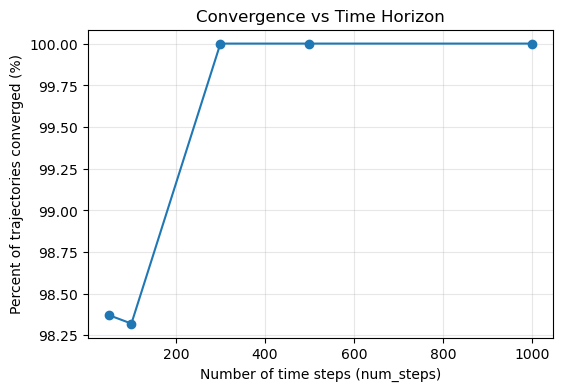

In [10]:
def test_halting(step_list, tolerance, loader):
# Different trajectory lengths (time horizons) to test
    
    converged_fracs = []

    print("Generating 10000 trajectories")
    for num_steps in step_list:
        #print(f"\nRunning trajectories with num_steps = {num_steps}...")
        all_halt_indices = find_attractor_indicies_batch(
            model,
            loader,
            num_steps=num_steps,
            eps_state=epsilon_state,
            device=device,
        )

        halt_arr = np.array(all_halt_indices)
        total_samples = halt_arr.shape[0]

        # Require that the halt index occurs at least 10 steps before the end
        # i.e., the trajectory stays in the ε-ball for the last 10 steps
        cutoff = num_steps*.8
        converged_mask = halt_arr < cutoff
        num_converged = converged_mask.sum()
        frac_converged = num_converged / total_samples

        converged_fracs.append(frac_converged)

        #print(f"Total trajectories: {total_samples}")
        #print(f"Converged before k={cutoff}: {num_converged}")
        print(f"Fraction converged before k={cutoff}: {frac_converged:.4f}")
        print(f"latest convergence ={max(halt_arr[converged_mask])}")
        print(f"average convergence point={sum(halt_arr[converged_mask])/sum(converged_mask)}")

    # ---- Plot fraction converged vs num_steps ----
    plt.figure(figsize=(6,4))
    plt.plot(step_list, np.array(converged_fracs) * 100.0, marker="o")
    plt.xlabel("Number of time steps (num_steps)")
    plt.ylabel("Percent of trajectories converged (%)")
    plt.title("Convergence vs Time Horizon")
    plt.grid(True, alpha=0.3)
    plt.show()
step_list = [50,100, 300, 500, 1000]
loader = test_loader
test_halting(step_list=step_list, tolerance=epsilon_state, loader=test_loader)


### 1.4 Intial analysis
This result is interesting and compelling for several reasons. The main reason this result is surprising is that even if there truely are attractors in our system that all trajectories converge to, our stict definition would likely still push the tail sum over our threshold over time. Despite this, we see all trajectories at the 1000 step trial converge in less than 150 time steps, meaning the sum of all 850 single step movements following was less than the average nearest neighbor distance between digits of the same class. 

## 2.0 Fixed Point Test

In order to study the SDAE as a dynamical system, we must observe how individual MNIST samples evolve under repeated application of the learned mapping: $x_{k+1} = f(x_k)$. The goal of this procedure is to compare the representations of the images across varying digit classes that they initially begin with. In doing this, we can find how strongly the SDAE contracts samples within the same class and whether different digit classes are pushed apart or pulled together across iterations. 


The function below implements this procedure. For each sample of the MNIST set, it: runs the DAE forward for a fixed number of steps, recording the $l_2$ step sizes between each iterations, applies the $\epsilon$-based halting rule defined above to detirmine the earliest iteration at which continuing iterations becomes negligable, re-runs the trajectory up to the halting index to obtain the actual halted state, and stores the noisy input, the halted point, and residual for later geometric and clustering analysis.

In [38]:
import numpy as np
from collections import Counter

# -------------------------------------------------------
# Collect dynamics samples (before/after DAE iteration)
@torch.no_grad()
def collect_dynamics_samples(model, loader, num_steps, eps_state, device="cpu", max_per_class=None):
    """

    For each example in the loader:
        - run x_{k+1} = f(x_k) for up to num_steps
        - record step sizes
        - determine halting index using eps_state
        - re-run only that sample's trajectory to get x_halt
        - compute residual ||f(x_halt) - x_halt||_2
        - store noisy, clean, halted, label
    """
    model.eval()

    dataset = loader.dataset

    # Pull MNIST labels in one place
    mnist_ds = dataset.mnist
    all_labels = mnist_ds.targets 


    # Storage lists
    final_points = []
    final_labels = []
    final_residuals = []
    orig_noisy_list = []
    orig_clean_list = []

    # Limits samples per class
    used = {d: 0 for d in range(10)}

    # Unified sample index
    idx = 0

    print("Collecting dynamics samples...")

    for noisy_batch, clean_batch in tqdm(loader):
        noisy_batch = noisy_batch.to(device)
        clean_batch = clean_batch.to(device)

        B = noisy_batch.size(0)

        # Collecting step sizes
        xk = noisy_batch.clone()
        step_sizes = []

        for _ in range(num_steps):
            x_next = model(xk)
            d = (x_next - xk).view(B, -1).norm(dim=1)
            step_sizes.append(d)
            xk = x_next

        # Stack to shape
        step_sizes = torch.stack(step_sizes, dim=1)

        # Process given sample
        for b in range(B):
            label = int(all_labels[idx])

            # Finding halt indez
            d_row = step_sizes[b].tolist()
            halt_idx = find_halt(d_row, eps_state)

            # Re-run sample trajectory until halting
            x_single = noisy_batch[b:b+1]
            for _ in range(halt_idx):
                x_single = model(x_single)

            x_halt = x_single

            # Find fixed-point residual
            res = model(x_halt) - x_halt
            residual = res.view(-1).norm().item()

            # Store results
            final_points.append(x_halt.view(-1).cpu().numpy())
            final_labels.append(label)
            final_residuals.append(residual)
            orig_noisy_list.append(noisy_batch[b].view(-1).cpu().numpy())
            orig_clean_list.append(clean_batch[b].view(-1).cpu().numpy())

            used[label] += 1
            idx += 1

    # Make arrays
    final_points = np.array(final_points)
    final_labels = np.array(final_labels)
    final_residuals = np.array(final_residuals)
    orig_noisy = np.array(orig_noisy_list)
    orig_clean = np.array(orig_clean_list)

    # Return final points, labels, residuals, original clean images and original noisy
    return final_points, final_labels, final_residuals, orig_clean, orig_noisy


In [39]:
# 600 appears to be sufficient # of iterations
num_steps = 600

# Enough to get metrics, yet small enough to not destroy memory
max_per_class = 700

(
    final_points,
    final_labels,
    final_residuals,
    orig_clean,
    orig_noisy,
) = collect_dynamics_samples(
    model=model,
    loader=test_loader,
    num_steps=num_steps,
    eps_state=epsilon_state,
    device=device,
    max_per_class=max_per_class,
)

print("Final points shape:", final_points.shape)
print("Orig clean shape:", orig_clean.shape)
print("Orig noisy shape:", orig_noisy.shape)
print("Residuals: mean =", final_residuals.mean(), ", median =", np.median(final_residuals))


100%|███████████████████████████████████████████| 79/79 [00:53<00:00,  1.49it/s]

Final points shape: (7000, 784)
Orig clean shape: (7000, 784)
Orig noisy shape: (7000, 784)
Residuals: mean = 0.7388134967865688 , median = 0.65983846783638


In [40]:
# Finding metrics
def pairwise_dists(X):
    """
    X: array of shape (N, D)
    returns: Euclidean distance matrix of shape (N, N)
    """
    diff = X[:, None, :] - X[None, :, :]
    dists = np.linalg.norm(diff, axis=-1)
    return dists

def pairwise_dists_cross(X, Y):
    """
    Euclidean distances between all pairs (x in X, y in Y).
    X: (N1, D), Y: (N2, D)
    returns: (N1, N2)
    """
    diff = X[:, None, :] - Y[None, :, :]
    dists = np.linalg.norm(diff, axis=-1)
    return dists

def compute_intra_inter_class_distances(points, labels):
    """
    Compute mean intra-class and inter-class distances for
    the given embedding 'points' and labels.
    
    Args:
        points: (N, D) numpy array
        labels: (N,)  numpy array of digits

    Returns:
        intra: dict[digit] -> mean intra-class distance
        inter: dict[(digit_i, digit_j)] -> mean distance between classes
    """
    digits = sorted(np.unique(labels))
    intra = {}
    inter = {}

    for d in digits:
        Xd = points[labels == d]
        if len(Xd) > 1:
            Dd = pairwise_dists(Xd)
            tri = np.triu_indices_from(Dd, k=1)
            intra[d] = Dd[tri].mean()
        else:
            intra[d] = np.nan

    for d1 in digits:
        for d2 in digits:
            if d1 == d2:
                continue
            X1 = points[labels == d1]
            X2 = points[labels == d2]
            Dij = pairwise_dists_cross(X1, X2)
            inter[(d1, d2)] = Dij.mean()

    return intra, inter

# Distances using denoising SDAE
intra_final, inter_final = compute_intra_inter_class_distances(final_points, final_labels)

print("Intra-class mean distances after denoising SDAE:")
for d in sorted(intra_final.keys()):
    print(f"  class {d}: {intra_final[d]:.4f}")

print("\nExample inter-class distances after denoising SDAE:")
for (d1, d2), val in list(inter_final.items())[:10]:
    print(f"  ({d1}, {d2}): {val:.4f}")


Intra-class mean distances AFTER dynamics:
  class 0: 7.9027
  class 1: 5.1916
  class 2: 7.8072
  class 3: 7.6649
  class 4: 6.1094
  class 5: 9.2402
  class 6: 3.8701
  class 7: 5.4826
  class 8: 8.2172
  class 9: 5.9420

Example inter-class distances AFTER dynamics:
  (0, 1): 12.2873
  (0, 2): 11.7513
  (0, 3): 10.5676
  (0, 4): 11.5687
  (0, 5): 10.4108
  (0, 6): 10.7198
  (0, 7): 11.5834
  (0, 8): 10.9571
  (0, 9): 11.3798
  (1, 0): 12.2873


In [49]:
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

# Cluster the original clean MNIST images
K = 10 # K image classes

kmeans_orig = KMeans(n_clusters=K, n_init=10, random_state=0, max_iter = 300)
clusters_orig = kmeans_orig.fit_predict(orig_clean)

# Evaluate with true labels
ari_orig = adjusted_rand_score(final_labels, clusters_orig)
nmi_orig = normalized_mutual_info_score(final_labels, clusters_orig)



In [50]:
# Finding same metrics as before:
# pairwise_dists, pairwise_dists_cross, compute_intra_inter_class_distances

# Distances using k-means on standard non-noisy
intra_clean, inter_clean = compute_intra_inter_class_distances(orig_clean, final_labels)

print("Intra-class mean distances after k-means on standard non-noisy MNIST:")
for d in sorted(intra_clean.keys()):
    print(f"  class {d}: {intra_clean[d]:.4f}")

print("\nExample inter-class distances after k-means standard non-noisy MNIST:")
for (d1, d2), val in list(inter_clean.items())[:10]:
    print(f"  ({d1}, {d2}): {val:.4f}")


Intra-class mean distances after k-means on standard non-noisy MNIST:
  class 0: 9.7262
  class 1: 5.9971
  class 2: 9.7299
  class 3: 9.1039
  class 4: 8.8750
  class 5: 9.5675
  class 6: 9.2533
  class 7: 8.4482
  class 8: 9.3085
  class 9: 8.5639

Example inter-class distances after k-means standard non-noisy MNIST:
  (0, 1): 11.1291
  (0, 2): 11.2699
  (0, 3): 10.9724
  (0, 4): 11.2098
  (0, 5): 10.6585
  (0, 6): 10.9119
  (0, 7): 11.1510
  (0, 8): 11.0293
  (0, 9): 11.0434
  (1, 0): 11.1291


In [53]:
# Comparing intra-class distances
print("\n=== Intra-class distances: Standard non-noisy MNIST k-means vs denoising SDAE ===")
for d in sorted(intra_clean.keys()):
    print(
        f"class {d}: "
        f"before = {intra_clean[d]:.4f}, "
        f"after = {intra_final[d]:.4f}"
    )



=== Intra-class distances: Standard non-noisy MNIST k-means vs denoising SDAE ===
class 0: before = 9.7262, after = 7.9027
class 1: before = 5.9971, after = 5.1916
class 2: before = 9.7299, after = 7.8072
class 3: before = 9.1039, after = 7.6649
class 4: before = 8.8750, after = 6.1094
class 5: before = 9.5675, after = 9.2402
class 6: before = 9.2533, after = 3.8701
class 7: before = 8.4482, after = 5.4826
class 8: before = 9.3085, after = 8.2172
class 9: before = 8.5639, after = 5.9420


For intra-clas distances, we measure how tightly the DAE collapses each digit in the feature space. For each class we we observe the $d_{intra} (c) = E_{i<j, y_i = y_j = c}||x_i - x_j||_2$ as the mean euclidean distance of each digit class from the original MNIST set. We observe here that digits 0, 2, 3, 4, 6, 7, and 9 show large reductions in intra-class distance. This shows us that the SDAE dynamics could drive samples toward tighter, lower-variance basins. The strongest of the contractions are:
Digit 6: 9.25 to 3.87
Digit 4: 8.88 to 6.20
Digit 7: 8.45 to 5.48.

We do see that digits 5 and 8 show minimal contraction. This leads us to believe that these digits may have multiple attractors, wider basins, or poorly defined flow fields.

In [54]:
# Comparing inter-class distances

pairs_to_check = [(0,1), (3,5), (4,9), (5,8)]


print("\n=== Inter-class distances: Standard non-noisy MNIST k-means vs denoising SDAE ===")
for (c, d) in pairs_to_check:
    bef = inter_clean[(c, d)]
    aft = inter_final[(c, d)]
    print(f"({c}, {d}): before = {bef:.4f}, after = {aft:.4f}")



=== Inter-class distances: Standard non-noisy MNIST k-means vs denoising SDAE ===
(0, 1): before = 11.1291, after = 12.2873
(3, 5): before = 9.8553, after = 9.2679
(4, 9): before = 9.0565, after = 7.0087
(5, 8): before = 9.9434, after = 9.4574


Observing the mean euclidean distances BETWEEN classes could also prove helpful here. For two seperate digit classes, we find $d_{inter}(c,d) = E_{i\in{c}, j\in{d}} ||x_i-x_j||_2$. We measured these distances with pairs usually confused for each other in ML clasification models. We observe here that the pair (0,1) becomes more seperated as it is iterated forward. This shows that the DAE could possibly be pushing classes farther apart from each other. Potentially improving global seperability. It should be noted however that the remainder of the inter-class distances decreased. This could show that the SDAE slightly merge or blur these classes in representation space. There is also a possibility that their basins of attraction overlap.

The combined results between the intra and inter class analysis provides evidence that the SDAE behaves as a contractive dynamical system on the MNIST dataset. It has shown to contract certain digit classes into tight attractor regions, it has increased global class speration in the observed pair of (0,1), however it should be noted that it collapsed on the manifolds of certain digit pairs. 

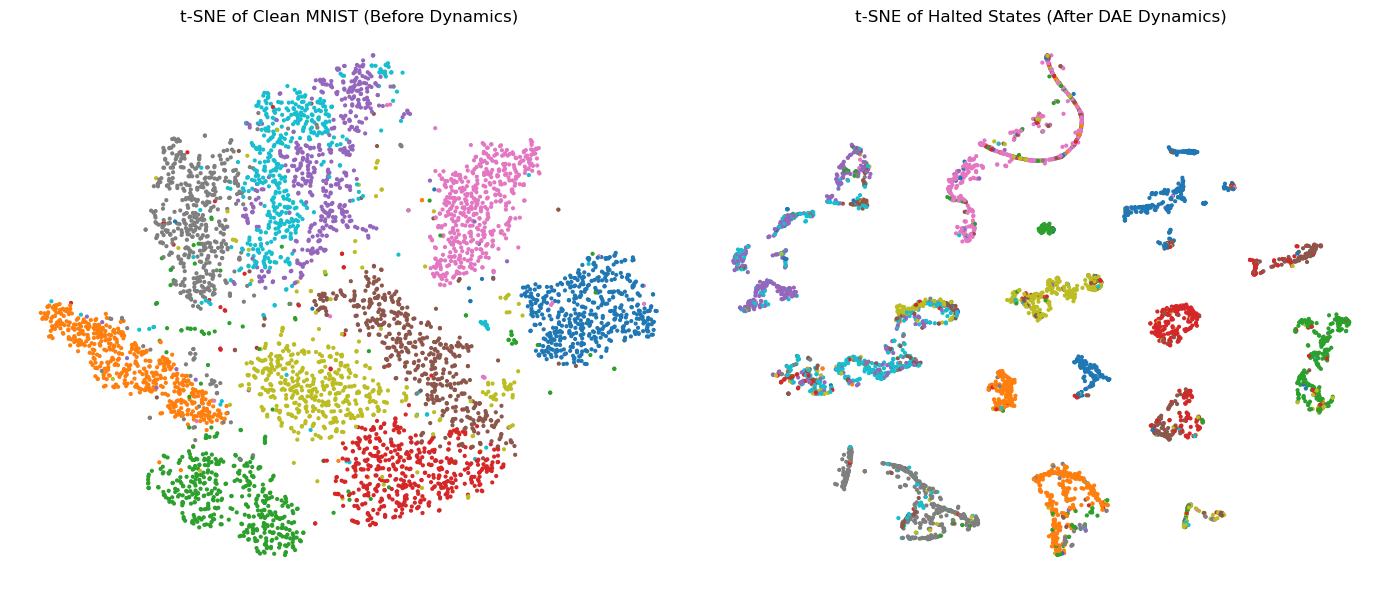

In [55]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Subsample for speed (optional but recommended)
N = min(5000, len(orig_clean))
idxs = np.random.choice(len(orig_clean), N, replace=False)

X_before = orig_clean[idxs]
X_after  = final_points[idxs]
y_subset = final_labels[idxs]

# t-SNE on BEFORE dynamics (clean MNIST)
tsne_before = TSNE(n_components=2, perplexity=40, learning_rate=200, random_state=0)
Z_before = tsne_before.fit_transform(X_before)

# t-SNE on AFTER dynamics (halted states)
tsne_after = TSNE(n_components=2, perplexity=40, learning_rate=200, random_state=0)
Z_after = tsne_after.fit_transform(X_after)

plt.figure(figsize=(14,6))

plt.subplot(1,2,1)
plt.scatter(Z_before[:,0], Z_before[:,1], c=y_subset, cmap='tab10', s=4)
plt.title("t-SNE of Clean MNIST (Before Dynamics)")
plt.axis('off')

plt.subplot(1,2,2)
plt.scatter(Z_after[:,0], Z_after[:,1], c=y_subset, cmap='tab10', s=4)
plt.title("t-SNE of Halted States (After DAE Dynamics)")
plt.axis('off')

plt.tight_layout()
plt.show()


By visualizing the t-SNE of the points, we can more 

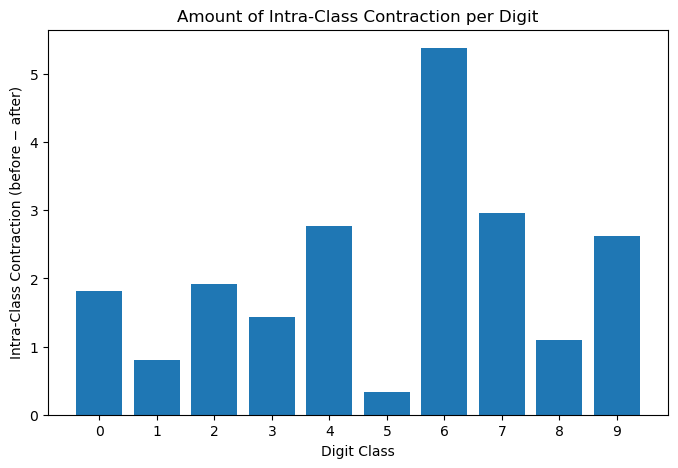

In [57]:
import matplotlib.pyplot as plt
import numpy as np

digits = sorted(intra_clean.keys())
before_vals = np.array([intra_clean[d] for d in digits])
after_vals  = np.array([intra_final[d] for d in digits])

contraction = before_vals - after_vals  # >0 means intra-class shrinkage

plt.figure(figsize=(8,5))
plt.bar(digits, contraction)
plt.xticks(digits)
plt.xlabel("Digit Class")
plt.ylabel("Intra-Class Contraction (before − after)")
plt.title("Amount of Intra-Class Contraction per Digit")
plt.show()


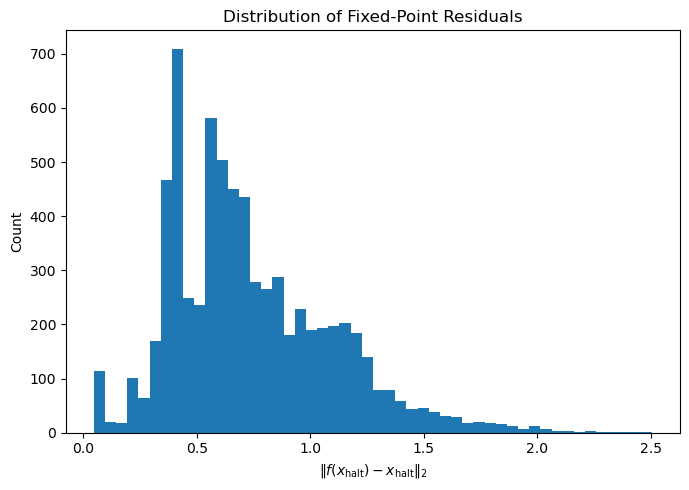

In [58]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
plt.hist(final_residuals, bins=50)
plt.xlabel(r"$\|f(x_{\mathrm{halt}}) - x_{\mathrm{halt}}\|_2$")
plt.ylabel("Count")
plt.title("Distribution of Fixed-Point Residuals")
plt.tight_layout()
plt.show()
